# Exploracion y entrenamiento del modelo

Proyecto final de Machine Learning, maestria en Ciencia de Datos, UNA Puno.

Pregunta del proyecto: que caracteristicas permiten anticipar que emprendimiento
tiene mayor probabilidad de sobrevivir.

Este cuaderno tiene todo el trabajo de principio a fin: mirar los datos, decidir
que columnas se usan, partir los datos, probar tres modelos, elegir el punto de
corte, medir cuanto aporta cada grupo de variables y guardar el modelo. De paso
genera las siete figuras que van en el informe.

No hay que correr nada antes ni importar nada del proyecto: el cuaderno se basta
solo. Lo unico que necesita es el archivo `data/startup_survival_master.csv`.

Al final hay una seccion que explica como este mismo codigo se paso despues a los
archivos `.py` de la carpeta `ml/`, que es lo que usa la aplicacion en produccion.

## 1. Preparar todo

In [1]:
# Se busca la carpeta del proyecto subiendo directorios hasta encontrar data/.
# Asi el cuaderno funciona igual abierto desde notebooks/ o desde la raiz.
from pathlib import Path

RAIZ = Path.cwd()
while not (RAIZ / "data" / "startup_survival_master.csv").exists():
    if RAIZ.parent == RAIZ:
        raise SystemExit("No encuentro el dataset. Abre el cuaderno dentro de Proyecto_Final_v2.")
    RAIZ = RAIZ.parent

print("proyecto:", RAIZ)

import json
import time
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 42     # para que los resultados salgan iguales cada vez que se corre

# Carpeta donde se guardan las figuras del informe
CARPETA_FIGURAS = RAIZ / "docs" / "figuras"
CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Colores fijos para todo el cuaderno, asi los graficos se ven iguales entre si
COLOR_FRACASO = "#d1495b"
COLOR_SOBREVIVE = "#2a9d8f"
COLOR_NEUTRO = "#4a7ba7"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10


def guardar(nombre):
    """Guarda el grafico actual en la carpeta de figuras del informe."""
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / f"{nombre}.png", bbox_inches="tight")

proyecto: /Users/hiroshitaco/CCProjects/Clau-Docs/Proyecto_Final_v2


## 2. Cargar los datos y mirarlos

Lo primero es abrir el archivo y ver que trae.

In [2]:
tabla = pd.read_csv(RAIZ / "data" / "startup_survival_master.csv")

print("filas:", len(tabla))
print("columnas:", len(tabla.columns))
tabla.head()

filas: 48000
columnas: 30


,startup_id,industry,founding_year,macro_climate,market_size_score,competition_intensity,founder_prior_exits,prior_failures,domain_experience_years,technical_cofounder,...,premature_scaling,pivots,unit_economics_score,marketing_effectiveness,weekly_hours,years_to_outcome,failure_reason,outcome,survived_5y,failed
0,STP000000,services,2017,2.9,0.0,0.3,0,0,5.3,1,...,0,0,2.9,7.5,51,2.7,team_conflict,failed,0,1
1,STP000001,marketplace,2016,7.0,6.6,2.7,0,0,1.7,0,...,0,0,3.6,5.9,57,1.5,no_market_need,failed,0,1
2,STP000002,services,2017,6.7,3.4,3.5,0,0,3.8,0,...,1,3,7.0,5.6,51,3.4,no_market_need,failed,0,1
3,STP000003,tech_saas,2012,4.4,7.7,5.5,0,0,3.1,0,...,1,1,4.8,6.8,73,3.2,ran_out_of_cash,failed,0,1
4,STP000004,consumer_app,2008,5.8,4.0,7.7,0,0,1.3,0,...,0,0,5.0,2.4,57,1.5,poor_marketing,failed,0,1


In [3]:
# Un resumen de las columnas numericas mas importantes
columnas = ["product_market_fit_score", "runway_months", "monthly_burn_rate",
            "cofounder_conflict", "team_completeness", "macro_climate"]
tabla[columnas].describe().round(2)

,product_market_fit_score,runway_months,monthly_burn_rate,cofounder_conflict,team_completeness,macro_climate
count,48000.00,48000.00,48000.00,48000.00,48000.00,48000.00
mean,4.61,18.88,99068.32,4.08,5.33,5.01
std,2.24,8.14,280512.74,2.22,2.16,1.98
min,0.00,2.00,500.00,0.00,0.00,0.00
25%,3.00,13.10,1200.00,2.50,3.88,3.70
50%,4.60,18.80,6300.00,4.00,5.30,5.00
75%,6.20,24.40,61500.00,5.60,6.80,6.40
max,10.00,50.00,3000000.00,10.00,10.00,10.00


Se ve enseguida algo en `monthly_burn_rate`: la mediana esta muy lejos del promedio.
Eso pasa porque unas pocas startups gastan muchisimo mas que el resto. Ese detalle
importa mas adelante, cuando haya que estandarizar.

## 3. Que columnas se pueden usar y cuales no

El archivo trae 30 columnas pero no todas sirven. Hay que descartar 13, por dos
motivos completamente distintos.

In [4]:
OBJETIVO = "failed"     # 1 si la startup fracaso, 0 si sobrevivio

# Estas columnas NO se pueden usar porque solo se conocen DESPUES de que la
# startup ya fracaso o sobrevivio. Usarlas seria hacer trampa: el modelo estaria
# leyendo la respuesta en vez de predecirla. A esto se le llama fuga de datos.
COLUMNAS_CON_FUGA = [
    "startup_id",        # identificador, no aporta nada
    "outcome",           # el desenlace en texto: failed, still_operating, acquired, ipo
    "failure_reason",    # por que fracaso, obviamente solo se sabe si fracaso
    "years_to_outcome",  # cuantos anios tardo en llegar al desenlace
    "survived_5y",       # si seguia viva a los 5 anios
    "failed",            # la variable objetivo
]

# Estas se midieron y no aportan nada al modelo. Se descartan para que el
# formulario de la web no le pida al usuario datos que no sirven.
COLUMNAS_SIN_APORTE = [
    "pivots", "technical_cofounder", "prior_failures", "weekly_hours",
    "founding_year", "n_cofounders", "age_of_founder",
]

print("columnas del archivo:", len(tabla.columns))
print("se descartan por fuga: ", len(COLUMNAS_CON_FUGA))
print("se descartan por inutiles:", len(COLUMNAS_SIN_APORTE))

columnas del archivo: 30
se descartan por fuga:  6
se descartan por inutiles: 7


Las 17 que quedan se organizan en seis grupos. Esta agrupacion no es decorativa:
es la que despues permite responder la pregunta del proyecto, midiendo cuanto
aporta cada grupo por separado.

In [5]:
GRUPOS = {
    "circumstance": ["macro_climate", "market_size_score", "competition_intensity"],
    "founder":      ["founder_prior_exits", "domain_experience_years"],
    "team":         ["cofounder_conflict", "team_completeness"],
    "execution":    ["product_market_fit_score", "did_customer_validation",
                     "premature_scaling", "unit_economics_score", "marketing_effectiveness"],
    "funding":      ["funding_path", "total_raised_usd", "monthly_burn_rate", "runway_months"],
    "context":      ["industry"],
}

# Nombre legible de cada grupo, para los graficos y la web
NOMBRES_DE_GRUPO = {
    "circumstance": "Circumstance and luck",
    "founder":      "Founder background",
    "team":         "Founding team",
    "execution":    "Execution",
    "funding":      "Funding and cash",
    "context":      "Context",
}

# La lista completa de variables sale de juntar todos los grupos
CARACTERISTICAS = []
for columnas_del_grupo in GRUPOS.values():
    CARACTERISTICAS.extend(columnas_del_grupo)

# Estas dos son texto, el resto son numeros
CATEGORICAS = ["industry", "funding_path"]
NUMERICAS = [c for c in CARACTERISTICAS if c not in CATEGORICAS]

print("variables que se usan:", len(CARACTERISTICAS))
print("  categoricas:", len(CATEGORICAS))
print("  numericas:  ", len(NUMERICAS))

variables que se usan: 17
  categoricas: 2
  numericas:   15


## 4. Cuantas startups fracasaron

Lo primero que hay que saber es como estan repartidas las dos clases, porque de eso
depende que metricas tienen sentido despues.

sobrevivieron: 16413  (34.2%)
fracasaron:    31587  (65.8%)


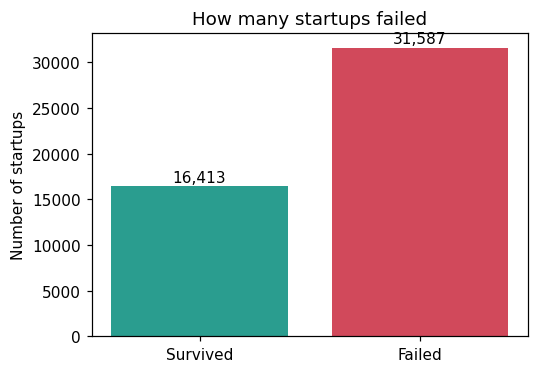

In [6]:
conteo = tabla["failed"].value_counts().sort_index()
sobrevivieron = conteo[0]
fracasaron = conteo[1]

print(f"sobrevivieron: {sobrevivieron}  ({100*sobrevivieron/len(tabla):.1f}%)")
print(f"fracasaron:    {fracasaron}  ({100*fracasaron/len(tabla):.1f}%)")

plt.figure(figsize=(5, 3.5))
plt.bar(["Survived", "Failed"], [sobrevivieron, fracasaron],
        color=[COLOR_SOBREVIVE, COLOR_FRACASO])
plt.ylabel("Number of startups")
plt.title("How many startups failed")

# Se escribe el numero encima de cada barra
plt.text(0, sobrevivieron + 500, f"{sobrevivieron:,}", ha="center")
plt.text(1, fracasaron + 500, f"{fracasaron:,}", ha="center")

guardar("01_balance_de_clases")
plt.show()

Casi dos de cada tres fracasan. Ese desbalance es el que mas adelante obliga a no
confiar en la exactitud ni en el F1, porque un modelo que diga "todas fracasan"
sacaria buena nota sin hacer nada.

## 5. Tasa de fracaso por industria

La pregunta aca es si hay sectores mas peligrosos que otros.

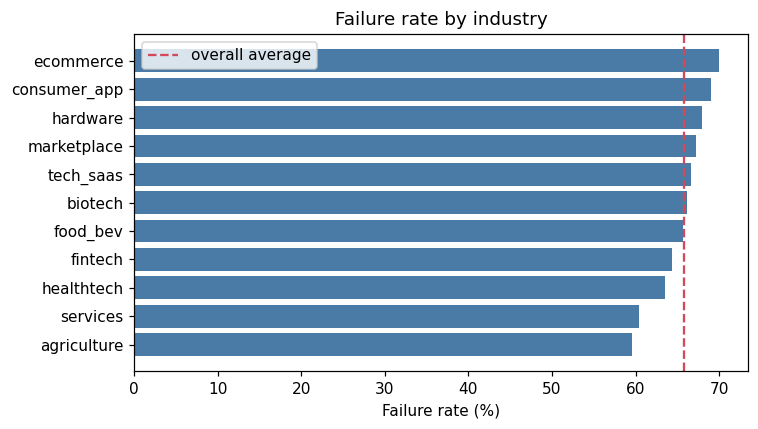

diferencia entre el sector mas y menos riesgoso: 10.4 puntos


In [7]:
por_industria = tabla.groupby("industry")["failed"].mean().sort_values()

plt.figure(figsize=(7, 4))
plt.barh(por_industria.index, 100 * por_industria.values, color=COLOR_NEUTRO)
plt.axvline(100 * tabla["failed"].mean(), color=COLOR_FRACASO,
            linestyle="--", label="overall average")
plt.xlabel("Failure rate (%)")
plt.title("Failure rate by industry")
plt.legend()

guardar("02_fracaso_por_industria")
plt.show()

print(f"diferencia entre el sector mas y menos riesgoso: "
      f"{100*(por_industria.max() - por_industria.min()):.1f} puntos")

La diferencia entre sectores es de apenas unos puntos. Eso ya adelanta algo que el
estudio de grupos confirma despues: la industria casi no sirve para predecir.

## 6. Las variables que si importan

Aca se mira como cambia la tasa de fracaso segun el valor de cada variable. Para eso
se parten los datos en cuatro grupos iguales, de menor a mayor.

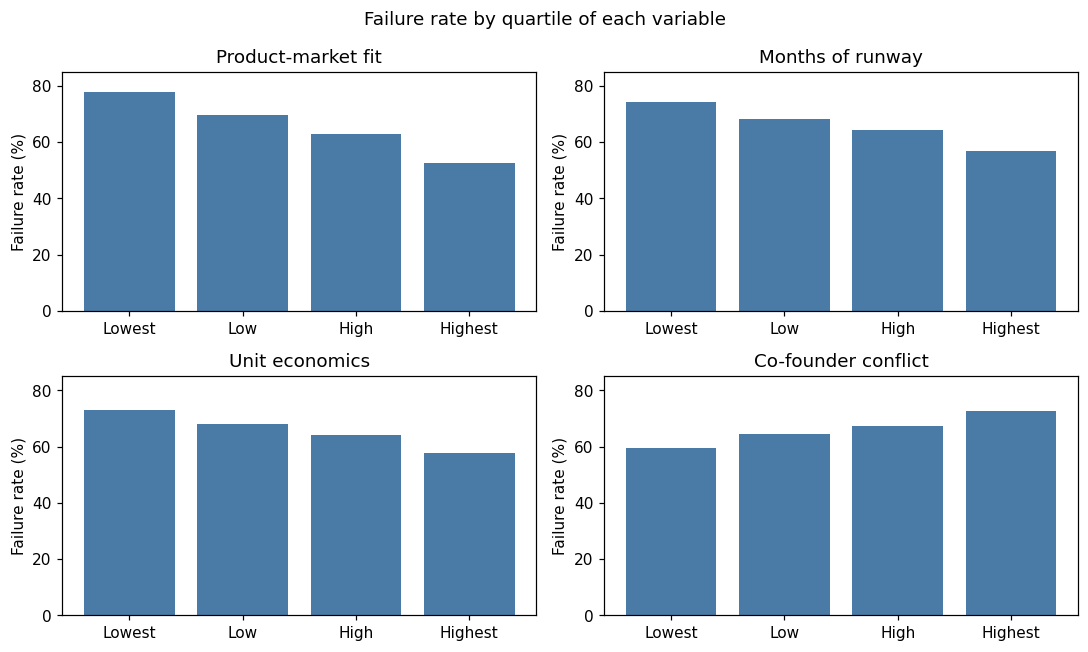

In [8]:
def tasa_por_cuartil(columna):
    """Divide la columna en 4 grupos iguales y calcula el fracaso de cada uno."""
    cuartiles = pd.qcut(tabla[columna], 4, labels=["Lowest", "Low", "High", "Highest"])
    return tabla.groupby(cuartiles, observed=True)["failed"].mean() * 100


variables = ["product_market_fit_score", "runway_months",
             "unit_economics_score", "cofounder_conflict"]
titulos = ["Product-market fit", "Months of runway",
           "Unit economics", "Co-founder conflict"]

plt.figure(figsize=(10, 6))

for i in range(len(variables)):
    plt.subplot(2, 2, i + 1)
    tasas = tasa_por_cuartil(variables[i])
    plt.bar(tasas.index, tasas.values, color=COLOR_NEUTRO)
    plt.ylabel("Failure rate (%)")
    plt.title(titulos[i])
    plt.ylim(0, 85)

plt.suptitle("Failure rate by quartile of each variable")
guardar("03_variables_importantes")
plt.show()

Los tres primeros bajan y el ultimo sube, que es justo lo esperable: mas encaje,
mas caja y mejores margenes protegen, mientras que mas conflicto entre socios
perjudica.

Fijarse en el segundo grafico, el de los meses de caja. Ahi se ve por que el
cuestionario para emprendedores calcula el runway en vez de preguntarlo.

## 7. Lo que no importa

Vale la pena graficar tambien las variables que no sirven, porque es un resultado
del proyecto y no una omision.

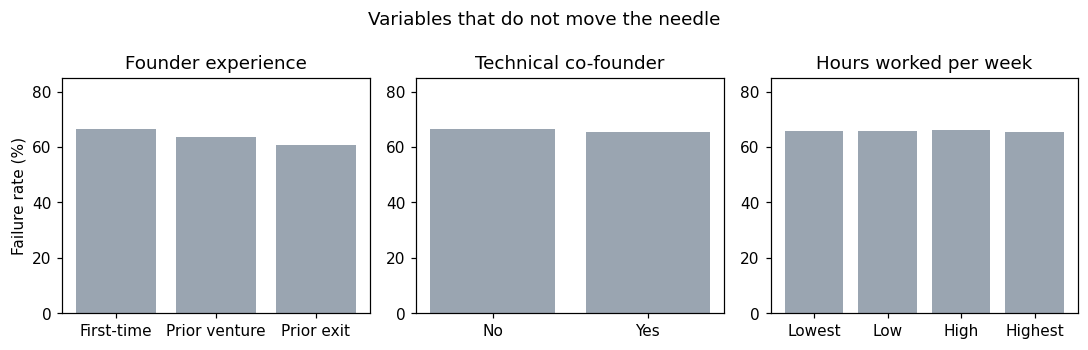

In [9]:
plt.figure(figsize=(10, 3.2))

plt.subplot(1, 3, 1)
tasas = tabla.groupby("founder_prior_exits")["failed"].mean() * 100
plt.bar(["First-time", "Prior venture", "Prior exit"], tasas.values, color="#9aa5b1")
plt.ylabel("Failure rate (%)"); plt.ylim(0, 85); plt.title("Founder experience")

plt.subplot(1, 3, 2)
tasas = tabla.groupby("technical_cofounder")["failed"].mean() * 100
plt.bar(["No", "Yes"], tasas.values, color="#9aa5b1")
plt.ylim(0, 85); plt.title("Technical co-founder")

plt.subplot(1, 3, 3)
tasas = tasa_por_cuartil("weekly_hours")
plt.bar(tasas.index, tasas.values, color="#9aa5b1")
plt.ylim(0, 85); plt.title("Hours worked per week")

plt.suptitle("Variables that do not move the needle")
guardar("04_variables_sin_efecto")
plt.show()

Las barras estan practicamente a la misma altura en los tres casos. Tener cofundador
tecnico, haber fundado antes o trabajar mas horas no cambia la tasa de fracaso.

## 8. Preparar las variables para el modelo

Hasta aca solo se miro. Ahora empieza el entrenamiento. El primer paso es separar
las variables predictoras, que se llaman X, de lo que se quiere predecir, que se
llama y.

In [10]:
def preparar(tabla):
    """Separa las variables predictoras (X) de lo que se quiere predecir (y)."""
    y = tabla[OBJETIVO]
    X = tabla[CARACTERISTICAS].copy()

    # Las categoricas se pasan a texto por si vinieran vacias. Un formulario web
    # tambien puede llegar incompleto, asi que conviene tener un valor de relleno.
    for columna in CATEGORICAS:
        X[columna] = X[columna].fillna("unknown").astype(str)

    # Las numericas que vengan mal se convierten a numero, y si no se puede, a cero.
    for columna in NUMERICAS:
        X[columna] = pd.to_numeric(X[columna], errors="coerce").fillna(0)

    return X, y


X, y = preparar(tabla)
print("X:", X.shape)
print("y:", y.shape, "| fracasaron:", y.sum(), f"({100*y.mean():.1f}%)")
X.head(3)

X: (48000, 17)
y: (48000,) | fracasaron: 31587 (65.8%)


,macro_climate,market_size_score,competition_intensity,founder_prior_exits,domain_experience_years,cofounder_conflict,team_completeness,product_market_fit_score,did_customer_validation,premature_scaling,unit_economics_score,marketing_effectiveness,funding_path,total_raised_usd,monthly_burn_rate,runway_months,industry
0,2.9,0.0,0.3,0,5.3,6.4,3.4,5.5,1,0,2.9,7.5,vc_series_a_plus,13264000.0,699600.0,19.0,services
1,7.0,6.6,2.7,0,1.7,1.5,4.9,1.9,0,0,3.6,5.9,bootstrapped,11000.0,700.0,15.7,marketplace
2,6.7,3.4,3.5,0,3.8,4.9,7.1,6.6,0,1,7.0,5.6,angel,201000.0,9400.0,21.4,services


## 9. Partir los datos en tres

Lo normal seria partir en dos, entrenamiento y prueba. Aca se parte en tres y vale
la pena explicar por que.

Hay dos decisiones distintas que tomar durante el entrenamiento: cuales son los
mejores hiperparametros, y cual es el punto de corte de la probabilidad. Si las dos
se tomaran con los mismos datos, la nota final saldria inflada. Entonces los
hiperparametros se buscan con el conjunto de entrenamiento, el punto de corte se
elige con el de validacion, y el de prueba no se toca hasta el final.

In [11]:
from sklearn.model_selection import train_test_split

# Primero se saca el 60% para entrenar y queda un 40% sobrante
X_entrenar, X_sobrante, y_entrenar, y_sobrante = train_test_split(
    X, y, test_size=0.4, random_state=SEMILLA, stratify=y)

# Ese 40% se parte por la mitad: 20% validacion y 20% prueba
X_validar, X_probar, y_validar, y_probar = train_test_split(
    X_sobrante, y_sobrante, test_size=0.5, random_state=SEMILLA, stratify=y_sobrante)

print("entrenamiento:", len(X_entrenar))
print("validacion:   ", len(X_validar))
print("prueba:       ", len(X_probar))

# stratify=y mantiene la misma proporcion de fracasos en las tres partes
print(f"\nfracaso en entrenamiento: {100*y_entrenar.mean():.1f}%")
print(f"fracaso en validacion:    {100*y_validar.mean():.1f}%")
print(f"fracaso en prueba:        {100*y_probar.mean():.1f}%")

entrenamiento: 28800
validacion:    9600
prueba:        9600

fracaso en entrenamiento: 65.8%
fracaso en validacion:    65.8%
fracaso en prueba:        65.8%


## 10. Preparar las columnas

Un modelo no entiende la palabra "fintech", asi que las columnas de texto hay que
convertirlas en numeros. Y las columnas numericas hay que ponerlas en la misma
escala, porque `total_raised_usd` llega a 52 millones y `product_market_fit_score`
va de 0 a 10: sin emparejar las escalas, la regresion logistica le daria mucha mas
importancia a la primera solo porque sus numeros son mas grandes.

Las dos cosas se hacen dentro de un `ColumnTransformer`, que aplica un tratamiento
distinto a cada juego de columnas.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def preparar_columnas(categoricas, numericas):
    """Deja las columnas listas para que el modelo las entienda.

    handle_unknown="ignore" es importante: si manana aparece una industria nueva
    que no estaba al entrenar, la API responde igual en vez de romperse.
    """
    convertir_categoricas = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    convertir_numericas = StandardScaler()
    return ColumnTransformer([
        ("categoricas", convertir_categoricas, categoricas),
        ("numericas", convertir_numericas, numericas),
    ])


# Se prueba para ver en cuantas columnas termina
prueba = preparar_columnas(CATEGORICAS, NUMERICAS)
resultado = prueba.fit_transform(X_entrenar)
print("columnas antes:  ", X_entrenar.shape[1])
print("columnas despues:", resultado.shape[1])

columnas antes:   17
columnas despues: 30


De 17 columnas se pasa a 32. La diferencia son las columnas nuevas que genera el
OneHotEncoder: una por cada industria y una por cada tipo de financiamiento.

## 11. Probar tres modelos

Se prueban tres algoritmos de naturaleza distinta: uno lineal, uno de arboles y uno
de potenciacion de gradiente. Para cada uno se prueban varias combinaciones de
hiperparametros con validacion cruzada y se guarda la mejor.

La busqueda es aleatoria y no exhaustiva porque probar todas las combinaciones
tardaria muchisimo, y casi siempre son pocos los hiperparametros que de verdad
cambian el resultado.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# Los tres modelos que se van a probar, cada uno con los valores que se le probaran
MODELOS = [
    {
        "nombre": "LogisticRegression",
        "modelo": LogisticRegression(max_iter=3000, random_state=SEMILLA),
        "opciones": {"modelo__C": [0.01, 0.1, 1.0, 10.0]},
    },
    {
        "nombre": "RandomForest",
        "modelo": RandomForestClassifier(random_state=SEMILLA, n_jobs=-1),
        "opciones": {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [6, 10, 16, None],
            "modelo__min_samples_leaf": [5, 20, 50],
        },
    },
    {
        "nombre": "HistGradientBoosting",
        "modelo": HistGradientBoostingClassifier(random_state=SEMILLA),
        "opciones": {
            "modelo__max_depth": [3, 6, None],
            "modelo__learning_rate": [0.05, 0.1],
            "modelo__max_iter": [200, 400],
            "modelo__min_samples_leaf": [20, 50],
        },
    },
]

print("se van a probar", len(MODELOS), "modelos")

reloj_total = time.time()   # para medir cuanto tarda todo el entrenamiento


se van a probar 3 modelos


In [14]:
# Esta celda tarda alrededor de medio minuto
validacion_cruzada = StratifiedKFold(5, shuffle=True, random_state=SEMILLA)
entrenados = {}

for candidato in MODELOS:
    nombre = candidato["nombre"]
    inicio = time.time()

    # El Pipeline junta la preparacion de columnas y el modelo en una sola pieza,
    # asi la preparacion se ajusta solo con los datos de entrenamiento
    modelo = Pipeline([
        ("preparacion", preparar_columnas(CATEGORICAS, NUMERICAS)),
        ("modelo", candidato["modelo"]),
    ])

    busqueda = RandomizedSearchCV(
        modelo,
        candidato["opciones"],
        n_iter=6,                  # se prueban 6 combinaciones al azar
        cv=validacion_cruzada,     # cada una con validacion cruzada de 5 pliegues
        scoring="roc_auc",
        random_state=SEMILLA,
        n_jobs=-1,
    )
    busqueda.fit(X_entrenar, y_entrenar)

    # Los nombres vienen como "modelo__C" y se les quita el prefijo
    opciones_ganadoras = {}
    for clave in busqueda.best_params_:
        opciones_ganadoras[clave.split("__")[-1]] = busqueda.best_params_[clave]

    entrenados[nombre] = {
        "modelo": busqueda.best_estimator_,
        "cv_roc_auc": float(busqueda.best_score_),
        "hyperparameters": opciones_ganadoras,
        "seconds": round(time.time() - inicio, 1),
    }

    print(f"{nombre:<22} AUC en validacion cruzada = {busqueda.best_score_:.4f}   "
          f"{opciones_ganadoras}   ({entrenados[nombre]['seconds']}s)")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=6. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LogisticRegression     AUC en validacion cruzada = 0.7456   {'C': 0.1}   (3.2s)


RandomForest           AUC en validacion cruzada = 0.7304   {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': None}   (17.6s)


HistGradientBoosting   AUC en validacion cruzada = 0.7358   {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 3, 'learning_rate': 0.05}   (4.1s)


## 12. Elegir el punto de corte

Aca esta la parte mas interesante del proyecto.

El modelo no devuelve un si o un no, devuelve una probabilidad. Hay que decidir a
partir de que numero se considera que la startup va a fracasar. Lo obvio seria usar
0.5, pero con las clases tan desbalanceadas ese valor no sirve.

Se probaron tres criterios y conviene compararlos antes de elegir.

In [15]:
from sklearn.metrics import (accuracy_score, average_precision_score,
                             balanced_accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)


def medir(y_real, probabilidades, umbral):
    """Calcula todas las notas del modelo con un punto de corte dado."""
    y_predicho = (probabilidades >= umbral).astype(int)
    matriz = confusion_matrix(y_real, y_predicho)

    return {
        "roc_auc": float(roc_auc_score(y_real, probabilidades)),
        "pr_auc": float(average_precision_score(y_real, probabilidades)),
        "accuracy": float(accuracy_score(y_real, y_predicho)),
        "balanced_accuracy": float(balanced_accuracy_score(y_real, y_predicho)),
        "precision": float(precision_score(y_real, y_predicho, zero_division=0)),
        "recall": float(recall_score(y_real, y_predicho, zero_division=0)),
        "f1": float(f1_score(y_real, y_predicho, zero_division=0)),
        "flagged_rate": float(y_predicho.mean()),
        "true_negatives": int(matriz[0][0]),
        "false_positives": int(matriz[0][1]),
        "false_negatives": int(matriz[1][0]),
        "true_positives": int(matriz[1][1]),
    }

In [16]:
# Se compara con el mejor modelo, que es la regresion logistica
modelo_prueba = entrenados["LogisticRegression"]["modelo"]
prob_validacion = modelo_prueba.predict_proba(X_validar)[:, 1]
prob_prueba = modelo_prueba.predict_proba(X_probar)[:, 1]

# --- Criterio 1: el valor por defecto de 0.5 ---
umbral_defecto = 0.5

# --- Criterio 2: el umbral que da el F1 mas alto ---
mejor_f1 = 0
umbral_f1 = 0.5
for corte in np.arange(0.05, 0.96, 0.01):
    puntaje = f1_score(y_validar, (prob_validacion >= corte).astype(int))
    if puntaje > mejor_f1:
        mejor_f1 = puntaje
        umbral_f1 = round(float(corte), 2)

# --- Criterio 3: el estadistico J de Youden ---
# J es sensibilidad mas especificidad menos uno. Obliga a acertar en las dos
# clases a la vez, asi que no se puede hacer trampa prediciendo siempre lo mismo.
falsos_positivos, verdaderos_positivos, umbrales = roc_curve(y_validar, prob_validacion)
puntaje_j = verdaderos_positivos - falsos_positivos
umbral_youden = round(float(umbrales[np.argmax(puntaje_j)]), 2)

print("umbral por defecto:", umbral_defecto)
print("umbral que maximiza F1:", umbral_f1)
print("umbral por J de Youden:", umbral_youden)

umbral por defecto: 0.5
umbral que maximiza F1: 0.37
umbral por J de Youden: 0.64


In [17]:
# Ahora se comparan los tres sobre el conjunto de prueba, mas el caso de no tener
# modelo, que es decir que todas fracasan
filas = []
for nombre, corte in [("Por defecto (0.5)", umbral_defecto),
                      ("Maximizar F1", umbral_f1),
                      ("J de Youden", umbral_youden)]:
    n = medir(y_probar, prob_prueba, corte)
    filas.append({"criterio": nombre, "umbral": corte,
                  "precision": round(n["precision"], 4),
                  "recall": round(n["recall"], 4),
                  "f1": round(n["f1"], 4),
                  "exactitud_balanceada": round(n["balanced_accuracy"], 4),
                  "señalados": f"{100*n['flagged_rate']:.1f}%"})

# El caso sin modelo: se marcan todas como fracaso
todas_fracasan = np.ones(len(y_probar))
filas.append({"criterio": "Sin modelo (todas fracasan)", "umbral": None,
              "precision": round(precision_score(y_probar, todas_fracasan), 4),
              "recall": 1.0,
              "f1": round(f1_score(y_probar, todas_fracasan), 4),
              "exactitud_balanceada": 0.5,
              "señalados": "100.0%"})

pd.DataFrame(filas)

,criterio,umbral,precision,recall,f1,exactitud_balanceada,señalados
0,Por defecto (0.5),0.50,0.7391,0.8756,0.8016,0.6405,77.9%
1,Maximizar F1,0.37,0.6975,0.9612,0.8084,0.5795,90.7%
2,J de Youden,0.64,0.7977,0.6965,0.7437,0.6783,57.5%
3,Sin modelo (todas fracasan),NaN,0.6580,1.0000,0.7937,0.5000,100.0%


Aca esta el problema. El criterio de maximizar F1 da el F1 mas alto de los tres,
pero al mismo tiempo la exactitud balanceada mas baja, y marca mas del 90 por ciento
de los casos. Comparado con la ultima fila, que es no tener modelo, la mejora en F1
es de apenas unas centesimas.

O sea que optimizando F1 el procedimiento estaba premiando justamente la estrategia
de marcar casi todo como fracaso. Por eso se adopta el J de Youden, que no permite
esa trampa porque obliga a acertar en las dos clases a la vez.

In [18]:
def elegir_umbral(y_real, probabilidades):
    """Elige el punto de corte con el estadistico J de Youden.

    El umbral se busca con los datos de validacion, nunca con los de prueba,
    porque si no la nota final saldria inflada.
    """
    falsos_positivos, verdaderos_positivos, umbrales = roc_curve(y_real, probabilidades)
    puntaje_j = verdaderos_positivos - falsos_positivos
    return round(float(umbrales[np.argmax(puntaje_j)]), 2)

## 13. Medir los tres modelos y quedarse con el mejor

Cada modelo elige su propio umbral con el conjunto de validacion, y despues se lo
mide sobre el conjunto de prueba, que hasta ahora no se habia tocado.

In [19]:
resultados = {}
mejor_nombre = ""
mejor_modelo = None
mejor_auc = 0.0
mejor_umbral = 0.5
mejores_opciones = {}

for nombre in entrenados:
    modelo = entrenados[nombre]["modelo"]

    # El umbral se elige con validacion
    umbral = elegir_umbral(y_validar, modelo.predict_proba(X_validar)[:, 1])

    # Y la nota se saca con prueba
    notas = medir(y_probar, modelo.predict_proba(X_probar)[:, 1], umbral)
    notas["cv_roc_auc"] = entrenados[nombre]["cv_roc_auc"]
    notas["hyperparameters"] = entrenados[nombre]["hyperparameters"]
    notas["threshold"] = umbral
    notas["seconds"] = entrenados[nombre]["seconds"]
    resultados[nombre] = notas

    print(f"{nombre:<22} AUC={notas['roc_auc']:.4f}  "
          f"balanceada={notas['balanced_accuracy']:.4f}  "
          f"precision={notas['precision']:.4f}  recall={notas['recall']:.4f}  "
          f"umbral={umbral}  marca {100*notas['flagged_rate']:.0f}%")

    if notas["roc_auc"] > mejor_auc:
        mejor_nombre = nombre
        mejor_modelo = modelo
        mejor_auc = notas["roc_auc"]
        mejor_umbral = umbral
        mejores_opciones = entrenados[nombre]["hyperparameters"]

print(f"\nGana {mejor_nombre} con AUC {mejor_auc:.4f} y umbral {mejor_umbral}")
print("hiperparametros:", mejores_opciones)

LogisticRegression     AUC=0.7469  balanceada=0.6783  precision=0.7977  recall=0.6965  umbral=0.64  marca 57%


RandomForest           AUC=0.7305  balanceada=0.6693  precision=0.7942  recall=0.6755  umbral=0.64  marca 56%


HistGradientBoosting   AUC=0.7363  balanceada=0.6674  precision=0.7907  recall=0.6823  umbral=0.64  marca 57%

Gana LogisticRegression con AUC 0.7469 y umbral 0.64
hiperparametros: {'C': 0.1}


Gana la regresion logistica, que es el modelo mas simple de los tres. Eso llama la
atencion, porque en datos de tabla los modelos de arboles suelen ganar. Que aca no
pase indica que las relaciones entre las variables y el fracaso son bastante
directas, sin interacciones raras que los arboles puedan aprovechar.

## 14. La matriz de confusion

Sirve para ver en que se equivoca el modelo, que es mas util que un solo numero.

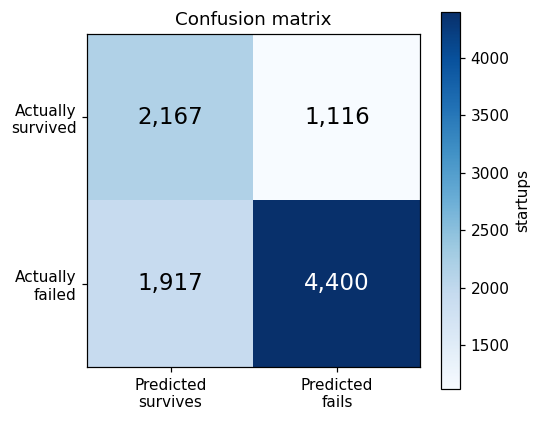

de las que fracasaron, detecta el 69.65%
de las que sobrevivieron, reconoce el 66.01%


In [20]:
notas = resultados[mejor_nombre]

matriz = np.array([[notas["true_negatives"], notas["false_positives"]],
                   [notas["false_negatives"], notas["true_positives"]]])

plt.figure(figsize=(5, 4.2))
plt.imshow(matriz, cmap="Blues")

# Se escribe cada numero encima de su casilla
for fila in range(2):
    for columna in range(2):
        valor = matriz[fila][columna]
        color = "white" if valor > matriz.max() / 2 else "black"
        plt.text(columna, fila, f"{valor:,}", ha="center", va="center",
                 fontsize=15, color=color)

plt.xticks([0, 1], ["Predicted\nsurvives", "Predicted\nfails"])
plt.yticks([0, 1], ["Actually\nsurvived", "Actually\nfailed"])
plt.title("Confusion matrix")
plt.colorbar(label="startups")

guardar("05_matriz_de_confusion")
plt.show()

detectados = 100 * notas["true_positives"] / (notas["true_positives"] + notas["false_negatives"])
reconocidos = 100 * notas["true_negatives"] / (notas["true_negatives"] + notas["false_positives"])
print(f"de las que fracasaron, detecta el {detectados:.2f}%")
print(f"de las que sobrevivieron, reconoce el {reconocidos:.2f}%")

Las dos tasas quedan bastante parejas. Eso no es casualidad: es consecuencia directa
del criterio de Youden, que obliga a acertar en las dos clases.

## 15. La curva ROC

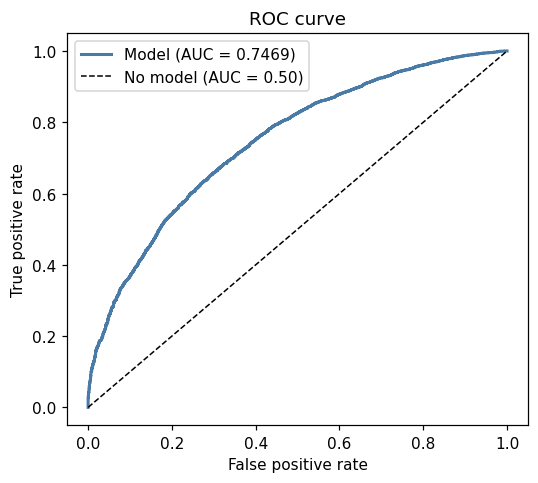

In [21]:
prob_final = mejor_modelo.predict_proba(X_probar)[:, 1]
falsos_positivos, verdaderos_positivos, _ = roc_curve(y_probar, prob_final)

plt.figure(figsize=(5, 4.5))
plt.plot(falsos_positivos, verdaderos_positivos, color=COLOR_NEUTRO, linewidth=2,
         label=f"Model (AUC = {notas['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="No model (AUC = 0.50)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()

guardar("06_curva_roc")
plt.show()

La linea diagonal es el modelo que no sabe nada. Mientras mas se despegue la curva
hacia arriba y a la izquierda, mejor distingue el modelo.

## 16. Que caracteristicas anticipan la supervivencia

Este es el resultado central del proyecto y la respuesta a la pregunta. Se mide de
dos formas que se complementan:

- solo: se entrena usando nada mas ese grupo, para ver cuanto predice por si solo
- sin: se entrena con todo menos ese grupo, y lo que se pierde dice cuanta
  informacion aportaba que no estuviera ya en los demas

Las dos hacen falta, porque un grupo puede predecir bien solo y aun asi ser
prescindible si su informacion ya esta duplicada en los otros.

In [22]:
def auc_usando(columnas):
    """Entrena una regresion logistica con las columnas que se le pasen y devuelve su AUC.

    Siempre usa el mismo algoritmo para que la comparacion entre grupos sea justa.
    """
    categoricas = [c for c in columnas if c in CATEGORICAS]
    numericas = [c for c in columnas if c not in CATEGORICAS]

    # Si un grupo no tiene columnas de algun tipo, ese paso no se agrega
    pasos = []
    if categoricas:
        pasos.append(("categoricas", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas))
    if numericas:
        pasos.append(("numericas", StandardScaler(), numericas))

    modelo = Pipeline([
        ("preparacion", ColumnTransformer(pasos)),
        ("modelo", LogisticRegression(max_iter=3000, random_state=SEMILLA)),
    ])

    X_a, X_b, y_a, y_b = train_test_split(
        X[columnas], y, test_size=0.2, random_state=SEMILLA, stratify=y)
    modelo.fit(X_a, y_a)
    return float(roc_auc_score(y_b, modelo.predict_proba(X_b)[:, 1]))

In [23]:
# Esta celda tarda unos segundos: entrena 13 modelos, uno con todo y dos por grupo
auc_con_todo = auc_usando(CARACTERISTICAS)
estudio = {"auc_con_todo": auc_con_todo, "grupos": {}}

print(f"AUC con las {len(CARACTERISTICAS)} variables: {auc_con_todo:.4f}\n")

for grupo in GRUPOS:
    columnas_del_grupo = GRUPOS[grupo]
    columnas_restantes = [c for c in CARACTERISTICAS if c not in columnas_del_grupo]

    auc_solo = auc_usando(columnas_del_grupo)
    auc_sin = auc_usando(columnas_restantes)

    estudio["grupos"][grupo] = {
        "nombre": NOMBRES_DE_GRUPO[grupo],
        "variables": columnas_del_grupo,
        "auc_solo_este_grupo": auc_solo,
        "auc_sin_este_grupo": auc_sin,
        "cuanto_se_pierde_al_quitarlo": auc_con_todo - auc_sin,
    }
    print(f"{NOMBRES_DE_GRUPO[grupo]:<24} solo={auc_solo:.4f}   "
          f"al quitarlo se pierde {auc_con_todo - auc_sin:+.4f}")

AUC con las 17 variables: 0.7422



Circumstance and luck    solo=0.5974   al quitarlo se pierde +0.0187


Founder background       solo=0.5430   al quitarlo se pierde +0.0039
Founding team            solo=0.5702   al quitarlo se pierde +0.0112


Execution                solo=0.6465   al quitarlo se pierde +0.0449
Funding and cash         solo=0.6420   al quitarlo se pierde +0.0470


Context                  solo=0.5347   al quitarlo se pierde +0.0030


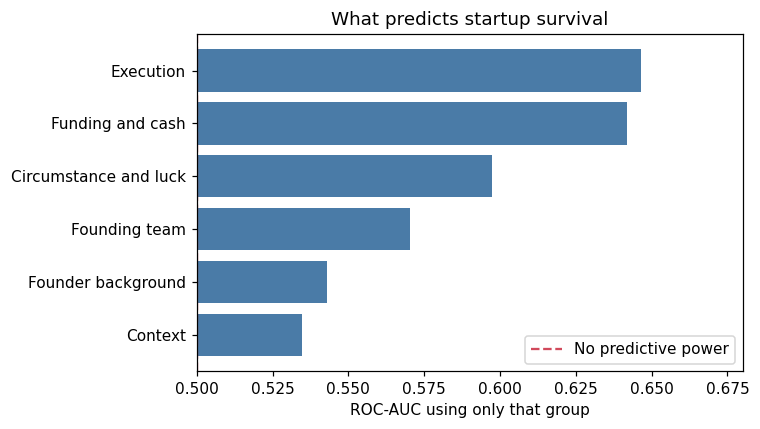

In [24]:
nombres = []
aportes = []
for grupo in estudio["grupos"]:
    nombres.append(estudio["grupos"][grupo]["nombre"])
    aportes.append(estudio["grupos"][grupo]["auc_solo_este_grupo"])

# Se ordenan de menor a mayor para que el grafico se lea de abajo hacia arriba
orden = np.argsort(aportes)
nombres = [nombres[i] for i in orden]
aportes = [aportes[i] for i in orden]

plt.figure(figsize=(7, 4))
plt.barh(nombres, aportes, color=COLOR_NEUTRO)
plt.axvline(0.5, color=COLOR_FRACASO, linestyle="--", label="No predictive power")
plt.xlim(0.5, 0.68)
plt.xlabel("ROC-AUC using only that group")
plt.title("What predicts startup survival")
plt.legend()

guardar("07_aporte_por_grupo")
plt.show()

Ejecucion y financiamiento estan arriba. El perfil del fundador esta casi pegado a la
linea roja, que marca el punto donde un grupo no aporta nada.

Lo llamativo es que la circunstancia, o sea la suerte del momento economico, predice
mejor que la trayectoria del fundador.

## 17. Guardar el modelo

El archivo que se guarda no lleva solo el modelo. Lleva tambien todo lo que la
aplicacion web necesita para armar sus formularios sola: que valores puede tomar
cada campo, en que rango se mueven los numeros, cual es el umbral y como le fue al
modelo. Asi, cuando se reentrena, la web se actualiza sola sin tocar una linea.

In [25]:
def opciones_de_formulario(X):
    """Valores posibles de las dos variables categoricas, para los desplegables."""
    opciones = {}
    for columna in CATEGORICAS:
        opciones[columna] = sorted(X[columna].unique().tolist())
    return opciones


def rangos_numericos(X):
    """Minimo, maximo y mediana de cada variable numerica, para los campos del formulario."""
    rangos = {}
    for columna in NUMERICAS:
        rangos[columna] = {
            "min": float(X[columna].min()),
            "max": float(X[columna].max()),
            "median": float(X[columna].median()),
        }
    return rangos


# Para explicar cada prediccion con SHAP hace falta saber como es la startup
# "promedio" contra la que se compara. Se guarda el promedio de los datos de
# entrenamiento ya transformados, porque la carpeta data/ no entra a la imagen
# de Docker y la API no podria calcularlo en produccion.
datos_transformados = mejor_modelo.named_steps["preparacion"].transform(X_entrenar)
fondo_shap = datos_transformados.mean(axis=0).tolist()

artefacto = {
    "pipeline": mejor_modelo,
    "model_version": "1.0.0",
    "model_name": mejor_nombre,
    "hyperparameters": mejores_opciones,
    "features": CARACTERISTICAS,
    "groups": GRUPOS,
    "group_names": NOMBRES_DE_GRUPO,
    "categorical_options": opciones_de_formulario(X),
    "numeric_ranges": rangos_numericos(X),
    "threshold": mejor_umbral,
    "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "rows": int(len(X)),
    "failure_rate": float(y.mean()),
    "metrics": resultados[mejor_nombre],
    "group_study": estudio,
    "shap_background": fondo_shap,
}

CARPETA_MODELOS = RAIZ / "models"
CARPETA_MODELOS.mkdir(parents=True, exist_ok=True)
joblib.dump(artefacto, CARPETA_MODELOS / "model.joblib")

# Aparte se guarda un JSON solo con los numeros, sin el modelo, para que el
# informe y el pipeline de mantenimiento puedan leerlo sin necesitar joblib.
reporte = {}
for clave in artefacto:
    if clave not in ("pipeline", "categorical_options", "numeric_ranges", "shap_background"):
        reporte[clave] = artefacto[clave]
reporte["all_models"] = resultados
reporte["training_seconds"] = round(time.time() - reloj_total, 1)

(CARPETA_MODELOS / "metrics.json").write_text(json.dumps(reporte, indent=2), encoding="utf-8")

print("modelo guardado en   ", CARPETA_MODELOS / "model.joblib")
print("metricas guardadas en", CARPETA_MODELOS / "metrics.json")

modelo guardado en    /Users/hiroshitaco/CCProjects/Clau-Docs/Proyecto_Final_v2/models/model.joblib
metricas guardadas en /Users/hiroshitaco/CCProjects/Clau-Docs/Proyecto_Final_v2/models/metrics.json


## 18. Resumen de hallazgos

| Hallazgo | Evidencia |
|---|---|
| El 65.8 por ciento de las startups fracasa | figura 1 |
| La industria casi no cambia el riesgo | figura 2 |
| Encaje, caja y margenes protegen; el conflicto perjudica | figura 3 |
| El perfil del fundador no mueve la aguja | figuras 4 y 7 |
| El modelo distingue bastante mejor que el azar | figuras 5 y 6 |
| Optimizar F1 daba un modelo que marcaba casi todo | seccion 12 |

Todas las figuras quedaron guardadas en `docs/figuras/` y se insertan en el informe
desde ahi.

## 19. De cuaderno a archivos .py

El cuaderno sirvio para explorar y para probar cosas, pero no sirve para produccion.
Una aplicacion web no puede depender de que alguien abra Jupyter y corra celdas en
orden, y el codigo de un cuaderno tampoco se puede probar automaticamente.

Por eso, una vez que el procedimiento quedo claro aca, se paso tal cual a archivos
`.py`, que es lo que usa la aplicacion. La correspondencia es directa:

| Del cuaderno | Se convirtio en |
|---|---|
| Seccion 3, las constantes y los grupos | `ml/config.py` |
| Seccion 8, la funcion `preparar` | `ml/data.py` |
| Secciones 9 a 17, todo el entrenamiento | `ml/train.py` |
| Nada, es nuevo | `app/main.py`, la API |
| Nada, es nuevo | `tests/`, las 29 pruebas |

El contenido es el mismo, lo que cambia es la forma. En `ml/train.py` los pasos
estan dentro de una funcion `entrenar()` que se puede llamar desde cualquier lado,
las constantes viven en un solo archivo para no repetirlas, y todo queda cubierto
por pruebas automaticas.

Para reentrenar el modelo desde la terminal, sin abrir el cuaderno:

    python -m ml.train

Ese comando hace exactamente lo mismo que las secciones 9 a 17 de este cuaderno y
produce el mismo `models/model.joblib`.